# CLV Segmentation and Campaign ROI

Operationalizes CLV predictions into actionable business outputs:

1. **4-tier customer segmentation** based on predicted CLV and P(purchase)
2. **Segment profiles**: size, avg CLV, predicted revenue, recommended actions
3. **Campaign ROI allocation table**: budget optimization by segment

**Outputs:**
- `data/processed/clv_final.csv` -- customers with segments and all CLV features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings('ignore')

# Paths
SCORED_PATH = "../data/processed/clv_scored.csv"
FINAL_PATH  = "../data/processed/clv_final.csv"

## 1. Load Data

In [2]:
df = pd.read_csv(SCORED_PATH)
print(f"Loaded {len(df):,} customers x {df.shape[1]} features")
print(f"\nCLV (12m) range: ${df['clv_12m'].min():.2f} -- ${df['clv_12m'].max():.2f}")
print(f"p_purchase range: {df['p_purchase'].min():.4f} -- {df['p_purchase'].max():.4f}")
print(f"Base purchase rate: {df['purchased_in_holdout'].mean():.1%}")

Loaded 4,918 customers x 25 features

CLV (12m) range: $0.00 -- $6213.12
p_purchase range: 0.0000 -- 0.9926
Base purchase rate: 52.0%


## 2. 4-Tier Customer Segmentation

| Segment | Definition | Recommended Action |
|---------|------------|--------------------|
| **High Value** | Top 20% CLV | No discounts -- protect margin |
| **At-Risk** | p_purchase < 0.20 (any CLV band) | Win-back campaign |
| **Growing** | Middle 40% CLV + p_purchase >= 0.20 | Personalized offers |
| **Low Value** | Bottom 40% CLV + p_purchase >= 0.20 | Email-only, minimal spend |

**Note:** At-Risk is checked across all CLV bands (except High Value) and takes priority over Growing/Low Value. The threshold of 0.20 is well below the ~52% base purchase rate, flagging customers with genuinely low engagement.

In [3]:
# Define CLV thresholds
P_PURCHASE_ATRISK = 0.20

clv_top20_threshold    = df['clv_12m'].quantile(0.80)
clv_bottom40_threshold = df['clv_12m'].quantile(0.40)

print(f"Segmentation thresholds:")
print(f"  Top 20% (High Value):   CLV > ${clv_top20_threshold:.2f}")
print(f"  Middle 40% (Growing):   ${clv_bottom40_threshold:.2f} < CLV <= ${clv_top20_threshold:.2f}")
print(f"  Bottom 40% (Low Value): CLV <= ${clv_bottom40_threshold:.2f}")
print(f"  At-Risk:                p_purchase < {P_PURCHASE_ATRISK} (overrides Growing/Low Value)")

def assign_segment(row):
    if row['clv_12m'] > clv_top20_threshold:
        return 'High Value'
    elif row['p_purchase'] < P_PURCHASE_ATRISK:
        return 'At-Risk'
    elif row['clv_12m'] > clv_bottom40_threshold:
        return 'Growing'
    else:
        return 'Low Value'

df['segment'] = df.apply(assign_segment, axis=1)

segment_counts = df['segment'].value_counts()
print(f"\nSegment distribution:")
for seg, cnt in segment_counts.items():
    print(f"  {seg:15s}: {cnt:,} customers ({cnt/len(df):.1%})")

Segmentation thresholds:
  Top 20% (High Value):   CLV > $3102.26
  Middle 40% (Growing):   $688.21 < CLV <= $3102.26
  Bottom 40% (Low Value): CLV <= $688.21
  At-Risk:                p_purchase < 0.2 (overrides Growing/Low Value)

Segment distribution:
  Growing        : 1,850 customers (37.6%)
  Low Value      : 1,127 customers (22.9%)
  High Value     : 984 customers (20.0%)
  At-Risk        : 957 customers (19.5%)


## 3. Segment Profiles

In [4]:
seg_order = ['High Value', 'Growing', 'At-Risk', 'Low Value']

seg_profile = df.groupby('segment').agg(
    n_customers        = ('user_id', 'count'),
    avg_clv_12m        = ('clv_12m', 'mean'),
    median_clv_12m     = ('clv_12m', 'median'),
    total_pred_revenue = ('clv_12m', 'sum'),
    avg_p_purchase     = ('p_purchase', 'mean'),
    avg_frequency      = ('frequency', 'mean'),
    avg_monetary       = ('monetary_value', 'mean'),
).round(2)

seg_profile['revenue_share'] = (
    seg_profile['total_pred_revenue']
    / seg_profile['total_pred_revenue'].sum() * 100
).round(1)

seg_profile = seg_profile.reindex(
    [s for s in seg_order if s in seg_profile.index]
)

print("=== Segment Profile ===")
print(seg_profile.to_string())

=== Segment Profile ===
            n_customers  avg_clv_12m  median_clv_12m  total_pred_revenue  avg_p_purchase  avg_frequency  avg_monetary  revenue_share
segment                                                                                                                             
High Value          984      5310.40         5676.61          5225433.56            0.85           9.44        665.99           60.0
Growing            1850      1481.19         1492.73          2740196.20            0.64           5.17        354.05           31.4
At-Risk             957       256.35          148.24           245328.37            0.11           0.34        257.95            2.8
Low Value          1127       447.35          447.23           504165.28            0.36           1.64        172.94            5.8


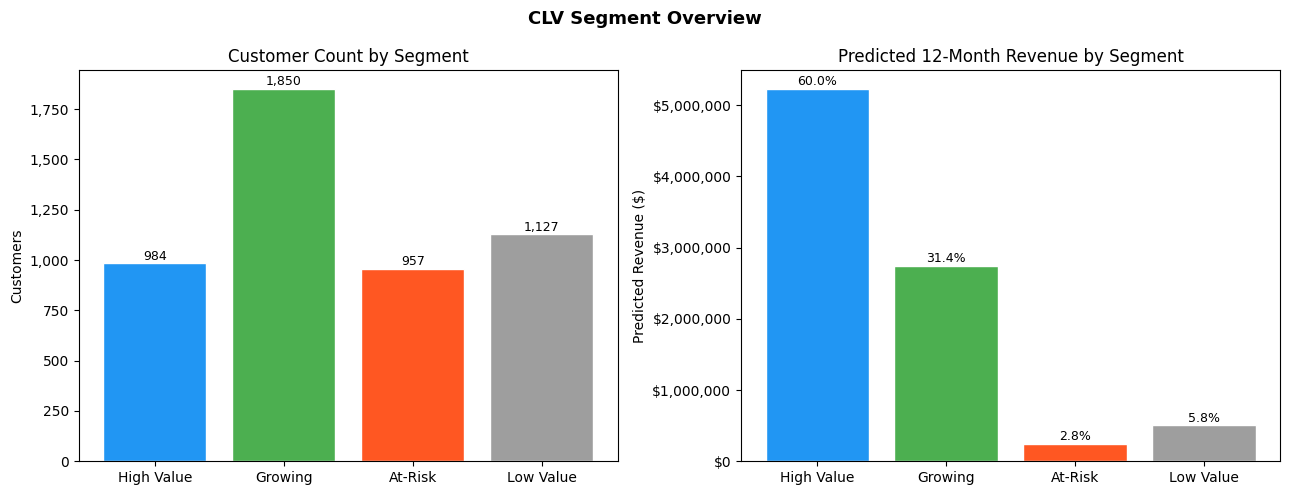

In [5]:
# Segment visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {
    'High Value': '#2196F3',
    'Growing':    '#4CAF50',
    'At-Risk':    '#FF5722',
    'Low Value':  '#9E9E9E',
}
segs = [s for s in seg_order if s in seg_profile.index]

# Customer count by segment
counts = [seg_profile.loc[s, 'n_customers'] for s in segs]
bar_colors = [colors[s] for s in segs]
axes[0].bar(segs, counts, color=bar_colors, edgecolor='white')
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts) * 0.01, f'{v:,}',
                ha='center', fontsize=9)

# Predicted revenue by segment
revenues = [seg_profile.loc[s, 'total_pred_revenue'] for s in segs]
axes[1].bar(segs, revenues, color=bar_colors, edgecolor='white')
axes[1].set_title('Predicted 12-Month Revenue by Segment')
axes[1].set_ylabel('Predicted Revenue ($)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
for i, (v, s) in enumerate(zip(revenues, segs)):
    share = seg_profile.loc[s, 'revenue_share']
    axes[1].text(i, v + max(revenues) * 0.01, f'{share:.1f}%',
                ha='center', fontsize=9)

plt.suptitle('CLV Segment Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Campaign ROI Allocation Table

| Segment | Budget/Customer | Conversion Rate | Rationale |
|---------|----------------|-----------------|----------|
| High Value | $0 (organic) | 40% | Retain naturally; discounts destroy margin |
| Growing | $15 | 25% | Personalized offer justified by growth potential |
| At-Risk | $10 | 15% | Win-back campaign; lower success rate |
| Low Value | $2 (email) | 5% | Email only; minimum investment |

In [6]:
campaign_params = {
    'High Value': {
        'budget_per_customer': 0,
        'conversion_rate': 0.40,
        'action': 'VIP loyalty -- no campaign',
    },
    'Growing': {
        'budget_per_customer': 15,
        'conversion_rate': 0.25,
        'action': 'Personalized offer',
    },
    'At-Risk': {
        'budget_per_customer': 10,
        'conversion_rate': 0.15,
        'action': 'Win-back campaign',
    },
    'Low Value': {
        'budget_per_customer': 2,
        'conversion_rate': 0.05,
        'action': 'Email only',
    },
}

roi_rows = []
for seg in seg_order:
    if seg not in seg_profile.index:
        continue
    params   = campaign_params[seg]
    n_cust   = seg_profile.loc[seg, 'n_customers']
    avg_clv  = seg_profile.loc[seg, 'avg_clv_12m']
    budget   = params['budget_per_customer']
    conv     = params['conversion_rate']

    total_cost    = budget * n_cust
    expected_rev  = avg_clv * conv * n_cust
    net_roi       = expected_rev - total_cost
    roi_pct       = (net_roi / total_cost * 100) if total_cost > 0 else float('inf')

    roi_rows.append({
        'Segment':             seg,
        'Customers':           n_cust,
        'Budget/Customer':     f'${budget}',
        'Conversion Rate':     f'{conv:.0%}',
        'Avg CLV':             f'${avg_clv:,.2f}',
        'Total Campaign Cost': f'${total_cost:,.0f}',
        'Expected Revenue':    f'${expected_rev:,.0f}',
        'Net ROI':             f'${net_roi:,.0f}',
        'ROI %':               f'{roi_pct:.0f}%' if total_cost > 0 else 'N/A (no spend)',
        'Action':              params['action'],
    })

roi_df = pd.DataFrame(roi_rows)
print("=== Campaign ROI Allocation Table ===")
print(roi_df.to_string(index=False))

=== Campaign ROI Allocation Table ===
   Segment  Customers Budget/Customer Conversion Rate   Avg CLV Total Campaign Cost Expected Revenue    Net ROI          ROI %                     Action
High Value        984              $0             40% $5,310.40                  $0       $2,090,173 $2,090,173 N/A (no spend) VIP loyalty -- no campaign
   Growing       1850             $15             25% $1,481.19             $27,750         $685,050   $657,300          2369%         Personalized offer
   At-Risk        957             $10             15%   $256.35              $9,570          $36,799    $27,229           285%          Win-back campaign
 Low Value       1127              $2              5%   $447.35              $2,254          $25,208    $22,954          1018%                 Email only


## 5. Discussion: Interpreting Negative ROI

If campaigns show negative ROI for some segments, the model is still valuable for:

1. **Identifying High Value customers to protect margin.** These customers purchase organically at high rates. The model identifies them so we avoid eroding their margin with unnecessary discounts.

2. **Prioritizing budget allocation across segments.** Even when no segment produces positive campaign ROI, the model tells us *where* each marketing dollar has the highest marginal return. Spending $15/customer on Growing is better than spending $15/customer on At-Risk.

3. **Setting data-driven budget caps per segment.** Negative ROI means the assumed budget/customer exceeds the expected incremental value. The model provides the ceiling: if Growing has avg CLV of $X and 25% conversion, then break-even budget is $X * 0.25 per customer. This replaces gut-feel budgeting with quantitative guardrails.

4. **Measuring what matters.** The campaign parameters above (budget, conversion rate) are *assumptions*. The CLV model is the *measurement*. When real campaign data becomes available, these assumptions get replaced with actuals, and the ROI table becomes a true P&L.

## 6. Save Final Outputs

In [7]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv(FINAL_PATH, index=False)
print(f"Final CLV data saved to {FINAL_PATH}")
print(f"  Shape: {df.shape[0]:,} customers x {df.shape[1]} columns")
print(f"  Key columns: segment, clv_12m, p_purchase, spend_tier")

Final CLV data saved to ../data/processed/clv_final.csv
  Shape: 4,918 customers x 26 columns
  Key columns: segment, clv_12m, p_purchase, spend_tier


In [8]:
print("=" * 55)
print("CLV SEGMENTATION SUMMARY")
print("=" * 55)
print(f"Total customers:      {len(df):,}")
print(f"Total predicted CLV:  ${df['clv_12m'].sum():,.0f}")
print(f"Median CLV:           ${df['clv_12m'].median():.2f}")
print()
for seg in seg_order:
    if seg in seg_profile.index:
        n   = int(seg_profile.loc[seg, 'n_customers'])
        rev = seg_profile.loc[seg, 'total_pred_revenue']
        pct = seg_profile.loc[seg, 'revenue_share']
        print(f"  {seg:15s}: {n:,} customers | ${rev:>10,.0f} predicted ({pct:.1f}%)")
print("=" * 55)
print("\nPipeline complete. Output: data/processed/clv_final.csv")

CLV SEGMENTATION SUMMARY
Total customers:      4,918
Total predicted CLV:  $8,715,123
Median CLV:           $951.72

  High Value     : 984 customers | $ 5,225,434 predicted (60.0%)
  Growing        : 1,850 customers | $ 2,740,196 predicted (31.4%)
  At-Risk        : 957 customers | $   245,328 predicted (2.8%)
  Low Value      : 1,127 customers | $   504,165 predicted (5.8%)

Pipeline complete. Output: data/processed/clv_final.csv
